In [ ]:
## installing  and importing dependencies

In [ ]:
!pip3 install torch torchvision
!pip install easyocr
!pip install matplotlib

In [ ]:
import easyocr
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#. 1. Reading Image

In [89]:
IMAGE_PATH = 'sign.png'

In [90]:
reader = easyocr.Reader(['en'], gpu= False)
result = reader.readtext(IMAGE_PATH)

# Convert numpy types to native Python types
cleaned_result = []
for bbox, text, score in result:
    # Convert bbox points to regular ints
    clean_bbox = [[int(x), int(y)] for x, y in bbox]
    # Convert score to float and round to 2 decimals
    clean_score = round(float(score), 2)
    cleaned_result.append((clean_bbox, text, clean_score))

print(cleaned_result)

Using CPU. Note: This module is much faster with a GPU.


[([[19, 181], [165, 181], [165, 201], [19, 201]], 'HEAD PROTECTION', 0.98), ([[31, 201], [153, 201], [153, 219], [31, 219]], 'MUST BE WORN', 0.98), ([[39, 219], [145, 219], [145, 237], [39, 237]], 'ON THIS SITE', 0.97)]


/opt/anaconda3/envs/ocr/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
#Drawing the Results

In [ ]:
top_left = tuple(result[0][0][0])
bottom_right = tuple(result[0][0][2])
text = result[0][1]
font = cv2.FONT_HERSHEY_SIMPLEX

In [ ]:
img = cv2.imread(IMAGE_PATH)
img = cv2.rectangle(img, top_left, bottom_right, (0,255,0), 1)
img = cv2.putText(img, text, top_left, font, .5, (255,0,0),2, cv2.LINE_AA)
plt.imshow(img)
plt.show()

In [ ]:
#HANDLING multpiple lines

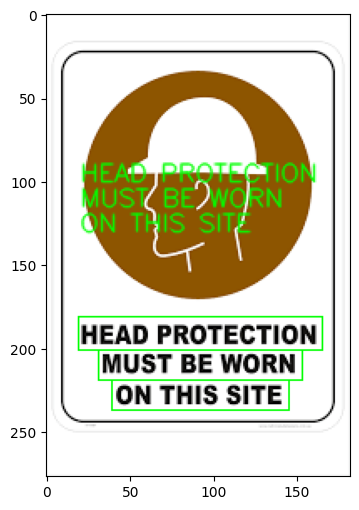

In [91]:
img = cv2.imread(IMAGE_PATH)
spacer = 100
for detection in result: 
    top_left = tuple([int(val) for val in detection[0][0]])
    bottom_right = tuple([int(val) for val in detection[0][2]])
    text = detection[1]
    font =cv2.FONT_HERSHEY_SIMPLEX
    img = cv2.rectangle(img, top_left, bottom_right, (0,255,0), 1)
    img = cv2.putText(img, text,(20, spacer), font, .5, (0,255,0),1, cv2.LINE_AA)
    spacer+=15
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.show()                      

In [92]:
#display the detected text
for detection in result:
    print(detection[1])


HEAD PROTECTION
MUST BE WORN
ON THIS SITE
